# Email Spam Filtering

**Problem Definition:** The [spam_ham_dataset](https://www.kaggle.com/datasets/venky73/spam-mails-dataset) is a dataset containing two folders of spam and ham.

The dataset can be utilized to develop a ML model that classifies emails into ham or spam.

In [7]:
## Dataset

## Dataset Columns
1. \# (length of email)
2. label (spam/ham)
3. text (data within email)
4. label number (if spam it's 1, or else it's 0)

## Vision & Mission
**Vision:** To set the foundations for highly secure & accurate email systems, capable of correctly classifying malicious emails and separating them from legitimate ones.

**Mission:** To develop a machine learning model that can accurately classify spam emails with minimal error.

## Gathering Data
[Data Source](https://www.kaggle.com/datasets/venky73/spam-mails-dataset
)

In [8]:
#@title Imports
## https://www.kaggle.com/datasets/venky73/spam-mails-dataset
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
nltk.download('stopwords')
from nltk.tokenize import RegexpTokenizer
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
!pip install gensim

In [10]:
import gensim
from gensim.models import Word2Vec

In [11]:
path = kagglehub.dataset_download("venky73/spam-mails-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.86M/1.86M [00:00<00:00, 82.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/venky73/spam-mails-dataset/versions/1


In [12]:
#@title Read data into Data-frame
df = pd.read_csv(path+"/spam_ham_dataset.csv")

# EDA

In [13]:
#@title General dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [14]:
#@title Sample of data

df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [15]:
df = df.rename(columns={'Unnamed: 0': 'length'})

In [16]:
df.head(2) # Double checking

,length,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0


In [17]:
#@title Describe data

df.describe()

,length,label_num
count,5171.000000,5171.000000
mean,2585.000000,0.289886
std,1492.883452,0.453753
min,0.000000,0.000000
25%,1292.500000,0.000000
50%,2585.000000,0.000000
75%,3877.500000,1.000000
max,5170.000000,1.000000


## Univariate Analysis

### Label

In [18]:
#@title Values for label target column

df["label"].value_counts()

,count
label,
ham,3672
spam,1499


/tmp/ipykernel_6547/3083250623.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Ham (0)', 'Spam (1)'])  # Custom labels


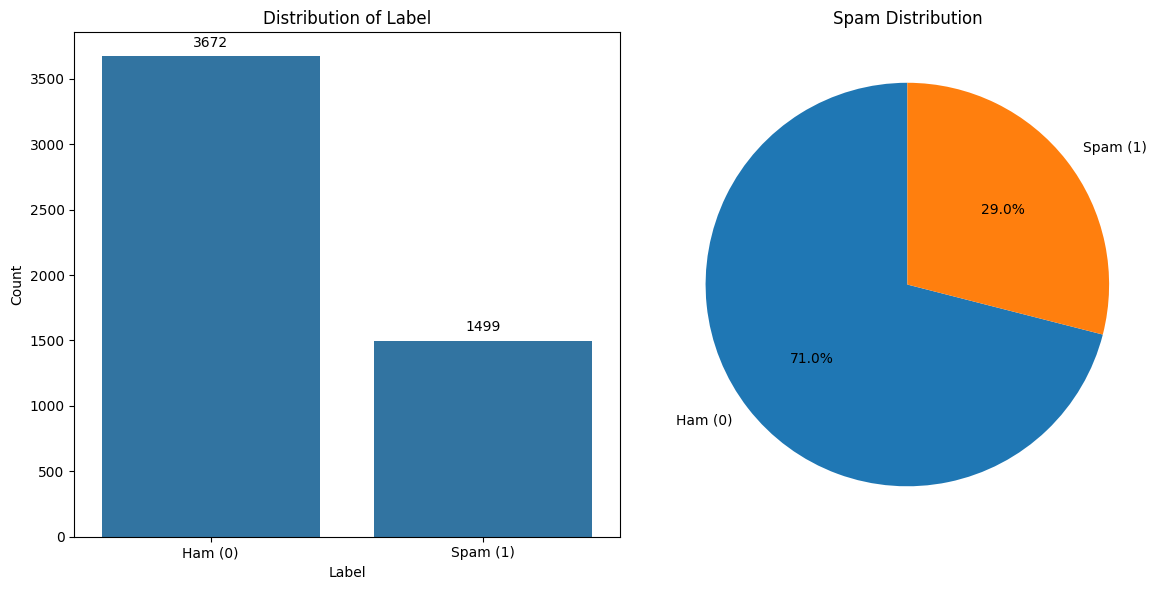

In [19]:
#@title Visualize target column (label)

# Set up the figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Count the occurrences of each category in the 'diabetes' column
diabetes_counts = df['label'].value_counts()

# Bar plot
sns.barplot(x=diabetes_counts.index, y=diabetes_counts.values, ax=ax[0])
ax[0].set_title('Distribution of Label')
ax[0].set_xlabel('Label')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Ham (0)', 'Spam (1)'])  # Custom labels

# Annotate each bar with its count
for i, count in enumerate(diabetes_counts):
    ax[0].text(i, count + 50, str(count), ha='center', va='bottom')

# Pie chart
ax[1].pie(diabetes_counts, labels=['Ham (0)', 'Spam (1)'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Spam Distribution')

# Display the plots
plt.tight_layout()
plt.show()

### Length

In [20]:
#@title length values

print("Summary statistics for length column:")
print("="*50)
print(df['length'].describe())

Summary statistics for length column:
count    5171.000000
mean     2585.000000
std      1492.883452
min         0.000000
25%      1292.500000
50%      2585.000000
75%      3877.500000
max      5170.000000
Name: length, dtype: float64


Does it make sense that some emails are completely empty? The answer is yes!

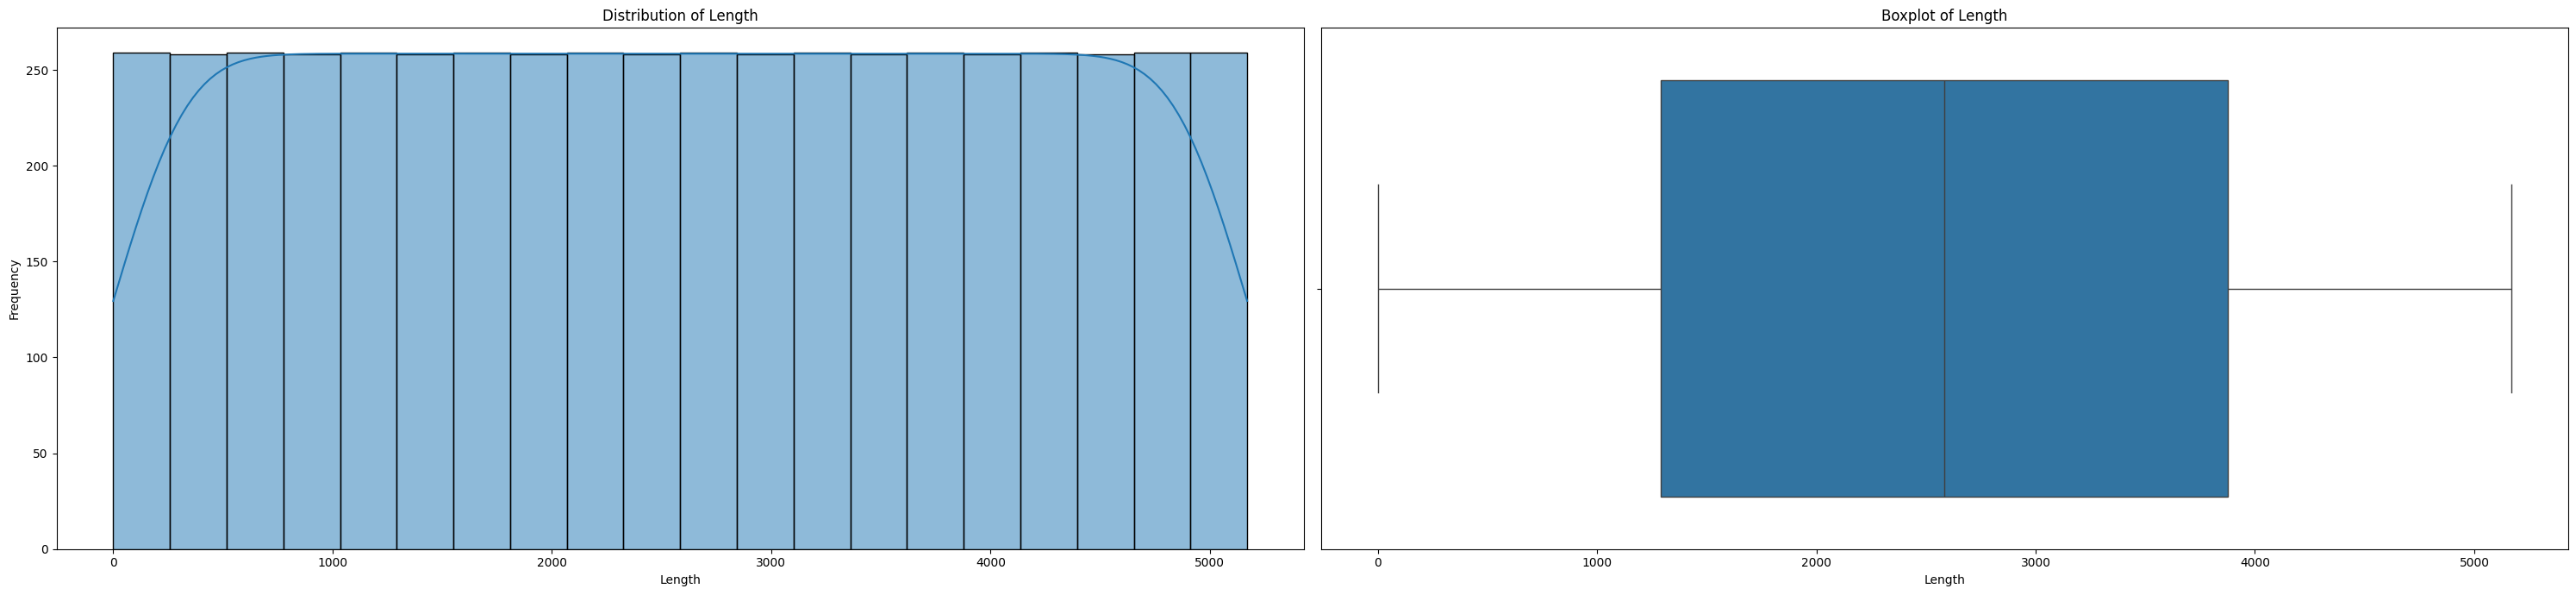

In [21]:
#@title Visualize distribution of length data

# Create a figure with two subplots: one for the histogram, one for the box plot
fig, axs = plt.subplots(1, 2, figsize=(30, 7))

# Histogram
sns.histplot(df['length'], bins=20, kde=True, ax=axs[0])
axs[0].set_title('Distribution of Length')
axs[0].set_xlabel('Length')
axs[0].set_ylabel('Frequency')


# Box plot
sns.boxplot(x=df['length'], orient="h", ax=axs[1])
axs[1].set_title('Boxplot of Length')
axs[1].set_xlabel('Length')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [22]:
#@title Check outliers of Length

q1 = df['length'].quantile(0.25)
q3 = df['length'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['length'] < lower_bound) | (df['length'] > upper_bound)]
print("Number of outliers for Length column:", len(outliers))
print("="*60)
print(outliers)

Number of outliers for Length column: 0
Empty DataFrame
Columns: [length, label, text, label_num]
Index: []


### Label Number

In [23]:
#@title Values for label number target column

df["label"].value_counts()

,count
label,
ham,3672
spam,1499


## Multivariate Analysis

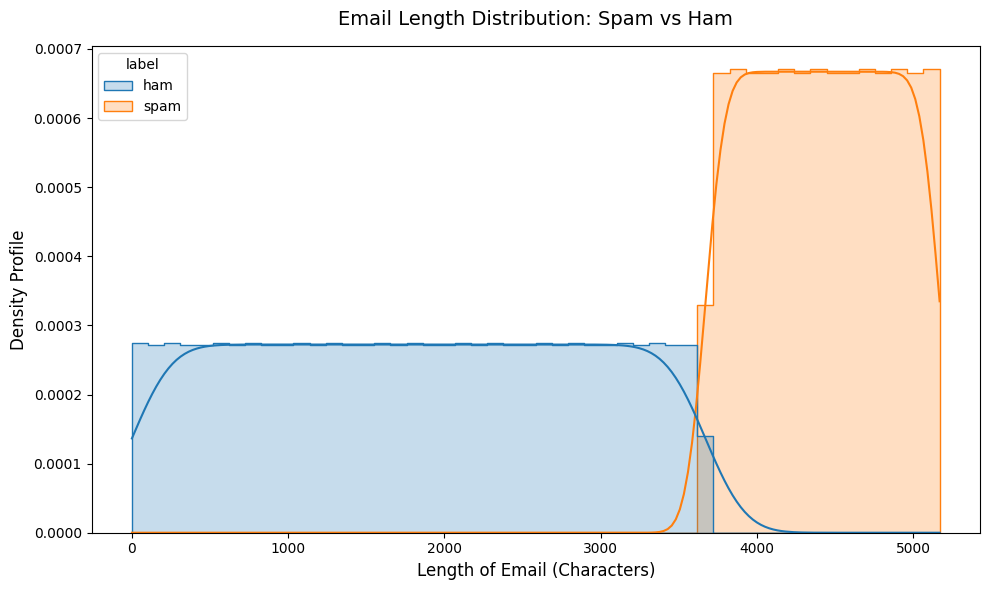

In [24]:
# Set up the plotting window
plt.figure(figsize=(10, 6))

# Create the overlaid histogram/KDE distribution plot
sns.histplot(
    data=df,
    x='length',
    hue='label',      # Colors the bars dynamically based on your Spam/Ham label
    kde=True,         # Draws a smooth distribution line over the bars
    bins=50,          # How granular you want the groupings to be
    element='step',   # Makes the overlapping steps visually distinct
    stat='density',   # Equalizes the counts so you can compare profiles even if you have less spam data
    common_norm=False # Prevents the dominant class from crushing the smaller class visually
)

# Label the charts neatly
plt.title('Email Length Distribution: Spam vs Ham', fontsize=14, pad=15)
plt.xlabel('Length of Email (Characters)', fontsize=12)
plt.ylabel('Density Profile', fontsize=12)

# Display the final plot
plt.tight_layout()
plt.show()

Seems like the higher the length of the characters, the more likely it is to be a spam email. Especially after approximately 3500~ characters.

# Data Preprocessing

First, we need to perform clearning of the text (handling text case, punctuations, and stopwords).
Then, we need to trasnform the text into numbers (embedding)

How?
1. Change all text to lowercase
2. Elimnate punctuations (substite with '')
3. Handling stopwords: Stop word (e.g, the, i, he, …), sklearn has a library of common stopwords.
4. Perform tokenization (can be done w/ scikit learn)
5. Select a word-embedding technique and use it

In [25]:
#@title Handling steps 1-4

stopWords = nltk.corpus.stopwords.words("english")

df['text'] = df['text'].astype("string") # Cast as string

df['text'] = df['text'].str.strip().str.lower() # Lowercase

# Removes stopwords
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopWords]))

# Tokenize & remove punctuation
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r'\w+')

df['text'] = df['text'].astype("string").apply(tokenizer.tokenize)

df.head()

,length,label,text,label_num
0,605,ham,"[subject, enron, methanol, meter, 988291, foll...",0
1,2349,ham,"[subject, hpl, nom, january, 9, 2001, see, att...",0
2,3624,ham,"[subject, neon, retreat, ho, ho, ho, around, w...",0
3,4685,spam,"[subject, photoshop, windows, office, cheap, m...",1
4,2030,ham,"[subject, indian, springs, deal, book, teco, p...",0


# Model Training
We are faced with some choices; what do we use for word embedding, and what model to use.

I'll be training models on both cbow and skipgram.

In [35]:
# Split data into train and test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'],
                                                    df['label_num'], test_size=0.2) # X is the text, Y is the label
X_train = X_train.reset_index(drop = True)
X_test = X_test.reset_index(drop = True)

# X_train and X_test already contain lists of tokens from previous preprocessing
X_train_tokens = X_train.values # This will be an array of lists of tokens
X_test_tokens = X_test.values # This will be an array of lists of tokens

In [27]:
# Word embedding

vector_dim = 100

model_cbow = gensim.models.Word2Vec(X_train_tokens, min_count=1,
                                vector_size=100, window=5) # This is CBOW (predict one word from context)

model_sg = gensim.models.Word2Vec(X_train_tokens, min_count=1,
                                vector_size=100, window=5, sg=1) # This is skipgram (predict similar context from word)



### Regression Model

Using cbow



In [28]:
# Transform emails into averaged word vectors
# (So they can be used by linear reg. model)
def document_vector(model, doc):
    doc = [word for word in doc if word in model.wv.index_to_key]
    if len(doc) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[doc], axis=0)


# Convert X_train_tokens and X_test_tokens to vectors using model_cbow
X_train_vectors = np.array([document_vector(model_cbow, doc) for doc in X_train_tokens])
X_test_vectors = np.array([document_vector(model_cbow, doc) for doc in X_test_tokens])

reg = linear_model.LinearRegression()
reg.fit(X_train_vectors, y_train)
print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

Coefficients: [-2.8002908  -1.0116454   3.2224116   0.17797858 -2.178844   -7.683573
  0.78647274 -1.7991736   0.75405633 -3.6891694   3.0914059   8.081975
  0.08700216  3.7431383   2.3401258  -1.757175    7.4750657  -1.5301832
  4.0231442  -4.893736   -4.1254797   0.4683391  -4.09449     0.2668751
  4.1605067  -1.652517    0.59246314 -5.0730443   4.710127   -3.2043648
 -3.9409676   0.05705455 -2.9733732   1.1150513   4.41682    -1.4441434
  0.17990309  3.3791065   1.6934128   1.4296062   1.2679363  -1.9760005
  4.7826986   2.8576992   3.8679652   0.46838093  1.4277861  -1.7050161
  2.8830352  -5.6488075  -0.5392575  -7.338964    5.607358   -1.7181392
  6.026038   -4.4502306  -1.2196802   0.22273147 -0.65558815 -4.4971285
 -4.0729184   4.4143386  -5.87274     5.769986   -2.728733   -1.747416
 -2.5636334  -2.0948474  -9.836177    4.031742    4.777127    6.868817
 -4.3428316   3.582253   -6.1143036  -1.9824982   4.8069715  -5.8018055
  2.3817306  -4.5694485   2.167984    3.9103746  -2.23

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_continuous = reg.predict(X_test_vectors)

# Binarize predictions for classification metrics (e.g., threshold at 0.5)
y_pred_binary = (y_pred_continuous > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

print("Model Evaluation Metrics:")
print("========================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Model Evaluation Metrics:
Accuracy:  0.9411
Precision: 0.8676
Recall:    0.9486
F1-Score:  0.9063


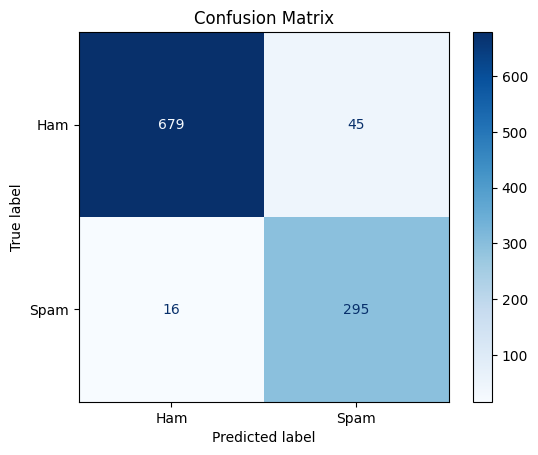

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Ham', 'Spam']) # Assuming 0 is Ham and 1 is Spam

# Plot the confusion matrix
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Using skipgram

In [32]:
# Transform emails into averaged word vectors
# (So they can be used by linear reg. model)
def document_vector(model, doc):
    doc = [word for word in doc if word in model.wv.index_to_key]
    if len(doc) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[doc], axis=0)


# Convert X_train_tokens and X_test_tokens to vectors using model_cbow
X_train_vectors = np.array([document_vector(model_sg, doc) for doc in X_train_tokens])
X_test_vectors = np.array([document_vector(model_sg, doc) for doc in X_test_tokens])

reg = linear_model.LinearRegression()
reg.fit(X_train_vectors, y_train)
print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

Coefficients: [-0.45455354  0.4206822   1.1417034   0.12970877  0.47443485  0.6966517
  0.57300067 -0.492482   -0.08509266  0.60048705  1.001766    0.5439378
 -0.088506    1.2841089  -0.14958763 -0.08681406  1.003672   -0.34764427
  0.81270313 -0.265797   -0.21240538  0.30864793 -0.20926383 -0.08630544
  0.7479977   0.58908284 -0.47661686 -0.16856648  0.56869465 -0.9664614
  0.305826   -0.5581858  -0.36166066 -0.3779567   0.07673681  0.94937986
 -0.6370648   0.17399104  0.38946098  0.6289429   0.05822322  0.03865968
  0.3800369   0.36982477  0.40982598 -0.85465145 -0.20866017 -0.3288981
 -0.18903272 -0.60436916 -0.25782424 -0.7303159   0.87203956 -0.62516576
  0.12038904 -0.4732811  -1.2636129   0.59583277 -0.0028464  -0.46663475
 -0.2491191   1.1183783   0.1319921   0.23835814 -0.12920944  0.12385583
 -0.07724339 -0.5058832  -1.6065409   0.4283216   0.438896   -0.51190877
  0.48747703  0.7330413  -0.02798606  0.5644752   0.39480808 -0.91844124
 -0.24374548 -0.00166672  0.54723376  0.7

In [33]:
# Make predictions on the test set
y_pred_continuous = reg.predict(X_test_vectors)

# Binarize predictions for classification metrics (e.g., threshold at 0.5)
y_pred_binary = (y_pred_continuous > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

print("Model Evaluation Metrics:")
print("========================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Model Evaluation Metrics:
Accuracy:  0.9594
Precision: 0.9216
Recall:    0.9453
F1-Score:  0.9333


We notice that skipgram yields better results.

Now let's try different models such as Naive Bayes, random forest, and SVM

### Naive Bayes

Naive Bayes Model Evaluation Metrics:
Accuracy:  0.9826
Precision: 0.9711
Recall:    0.9711
F1-Score:  0.9711


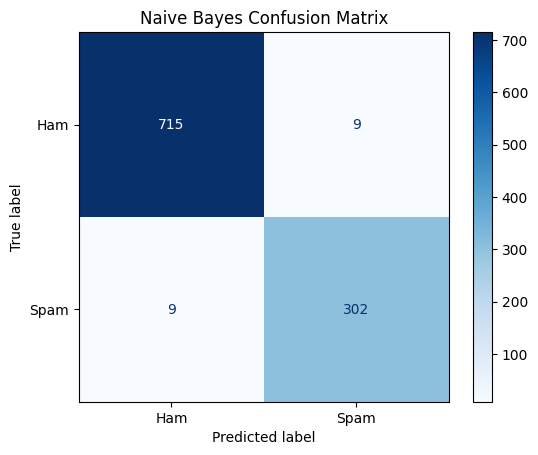

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Convert tokenized text back to strings for CountVectorizer
X_train_str = [' '.join(doc) for doc in X_train_tokens]
X_test_str = [' '.join(doc) for doc in X_test_tokens]

# Transform text data into feature vectors
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train_str)
X_test_counts = vectorizer.transform(X_test_str)

# Train Naive Bayes Classifier
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_counts, y_train)

# Make predictions on the test set
y_pred_nb = naive_bayes_model.predict(X_test_counts)

# Calculate and print metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Model Evaluation Metrics:")
print("====================================")
print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")

# Plot confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                                 display_labels=['Ham', 'Spam'])
disp_nb.plot(cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

Random Forest Model Evaluation Metrics:
Accuracy:  0.6589
Precision: 0.2614
Recall:    0.0740
F1-Score:  0.1153


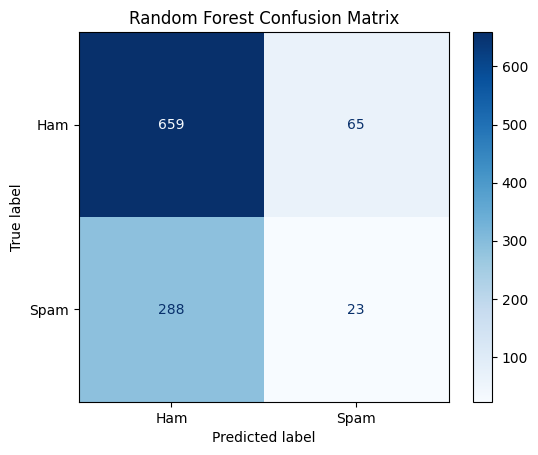

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Train Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train_counts, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test_counts)

# Calculate and print metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Model Evaluation Metrics:")
print("=======================================")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

# Plot confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                 display_labels=['Ham', 'Spam'])
disp_rf.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()